# Übung 7: KNN-Klassifikation

Datensatz: `tweet_emotion_clean.parquet` – 39.827 bereinigte Tweets mit 13 Emotions-Klassen.

Ziel: Ein K-Nearest-Neighbors-Modell zur Emotionserkennung trainieren, das optimale k auf einem Validierungsset bestimmen und den Einfluss verschiedener Vorverarbeitungsschritte auf die Modellgüte untersuchen.

In [1]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import f1_score, classification_report, confusion_matrix

plt.rcParams["figure.figsize"] = (12, 5)

## 1 Daten laden

In [2]:
df = pl.read_parquet("../data/tweet_emotion_clean.parquet")
texts  = df["content_clean"].to_list()
labels = df["emotion"].to_list()

print(f"Tweets gesamt: {len(texts):,}")
print(f"Klassen:       {df['emotion'].n_unique()}")

class_dist = df["emotion"].value_counts().sort("count", descending=True)
class_dist

Tweets gesamt: 39,827
Klassen:       13


emotion,count
str,u32
"""neutral""",8598
"""worry""",8437
"""happiness""",5184
"""sadness""",5154
"""love""",3785
…,…
"""hate""",1322
"""empty""",822
"""enthusiasm""",758


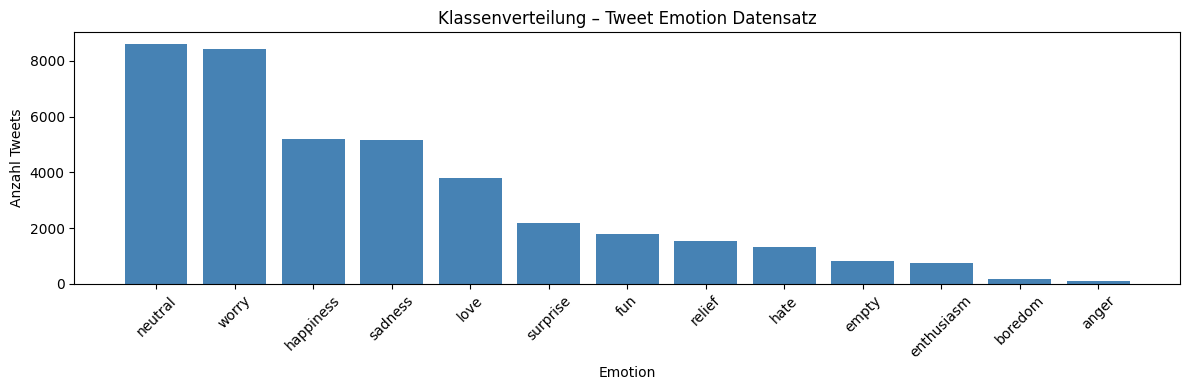

In [3]:
fig, ax = plt.subplots(figsize=(12, 4))
class_pd = class_dist.to_pandas()
ax.bar(class_pd["emotion"], class_pd["count"], color="steelblue")
ax.set_title("Klassenverteilung – Tweet Emotion Datensatz")
ax.set_xlabel("Emotion")
ax.set_ylabel("Anzahl Tweets")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("../assets/knn_klassenverteilung.png", dpi=150, bbox_inches="tight")
plt.show()

## 2 Stichprobe & Vektorisierung

KNN speichert alle Trainingspunkte und berechnet bei jeder Vorhersage den Abstand zu allen gespeicherten Punkten. Bei 39.827 Tweets wird das rechenintensiv. Wir arbeiten daher mit einer stratifizierten Stichprobe von 5.000 Tweets – die Klassenverteilung bleibt dabei erhalten.

Als Vektorisierung verwenden wir TF-IDF aus Notebook 6, da es bedeutungslose häufige Wörter automatisch abwertet.

In [4]:
# Stratifizierte Stichprobe: 5.000 Tweets
sss = StratifiedShuffleSplit(n_splits=1, train_size=5000, random_state=42)
idx_sub = next(sss.split(texts, labels))[0]
texts_sub  = [texts[i]  for i in idx_sub]
labels_sub = [labels[i] for i in idx_sub]

print(f"Stichprobengröße: {len(texts_sub):,}")

# TF-IDF – 500 Features, englische Stop Words entfernt
vectorizer = TfidfVectorizer(stop_words="english", max_features=500)
X = vectorizer.fit_transform(texts_sub)

print(f"Feature-Matrix:   {X.shape}  (Dokumente × Token)")

Stichprobengröße: 5,000
Feature-Matrix:   (5000, 500)  (Dokumente × Token)


## 3 Trainings-, Validierungs- und Testdaten

Das Modell lernt auf den Trainingsdaten. Das Validierungsset dient dazu, den Hyperparameter k zu wählen, ohne dabei den Testdatensatz zu berühren. Erst am Ende wird das finale Modell einmalig auf den Testdaten bewertet.

In [5]:
# Erst Trainings+Val vs. Test aufteilen (85% / 15%)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, labels_sub, test_size=0.15, random_state=42, stratify=labels_sub
)

# Dann Trainings vs. Validierung aufteilen (~70% / 15%)
val_ratio = 0.15 / 0.85
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=val_ratio, random_state=42, stratify=y_trainval
)

print(f"Training:     {X_train.shape[0]:>5} Samples  ({X_train.shape[0]/5000:.0%})")
print(f"Validierung:  {X_val.shape[0]:>5} Samples  ({X_val.shape[0]/5000:.0%})")
print(f"Test:         {X_test.shape[0]:>5} Samples  ({X_test.shape[0]/5000:.0%})")

Training:      3500 Samples  (70%)


Validierung:    750 Samples  (15%)
Test:           750 Samples  (15%)


## 4 Bestes k bestimmen

k ist der wichtigste Hyperparameter beim KNN-Algorithmus: Er legt fest, wie viele Nachbarn bei der Klassifikation berücksichtigt werden. Ein kleines k (z. B. k=1) reagiert empfindlich auf einzelne Ausreißer (Overfitting), ein großes k glättet die Entscheidungsgrenze, kann aber Feinheiten verlieren (Underfitting).

Als Evaluationsmetrik verwenden wir den **Macro F1-Score**, da er alle 13 Klassen gleich gewichtet – auch solche, die selten vorkommen.

Als Abstandsmaß nutzen wir die **Kosinus-Distanz**, die bei Textvektoren besser geeignet ist als euklidischer Abstand, weil sie die Richtung der Vektoren vergleicht und nicht ihre absolute Länge.

In [6]:
k_values = [1, 3, 5, 7, 11, 21]
val_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, metric="cosine", algorithm="brute", n_jobs=-1)
    knn.fit(X_train, y_train)
    y_pred_val = knn.predict(X_val)
    score = f1_score(y_val, y_pred_val, average="macro")
    val_scores.append(score)
    print(f"k={k:>2}  →  Macro F1 (Val): {score:.4f}")

best_k = k_values[np.argmax(val_scores)]
print(f"\nBestes k: {best_k}  (F1 = {max(val_scores):.4f})")

k= 1  →  Macro F1 (Val): 0.1114


k= 3  →  Macro F1 (Val): 0.1311


k= 5  →  Macro F1 (Val): 0.1256
k= 7  →  Macro F1 (Val): 0.1212


k=11  →  Macro F1 (Val): 0.1280
k=21  →  Macro F1 (Val): 0.1264

Bestes k: 3  (F1 = 0.1311)


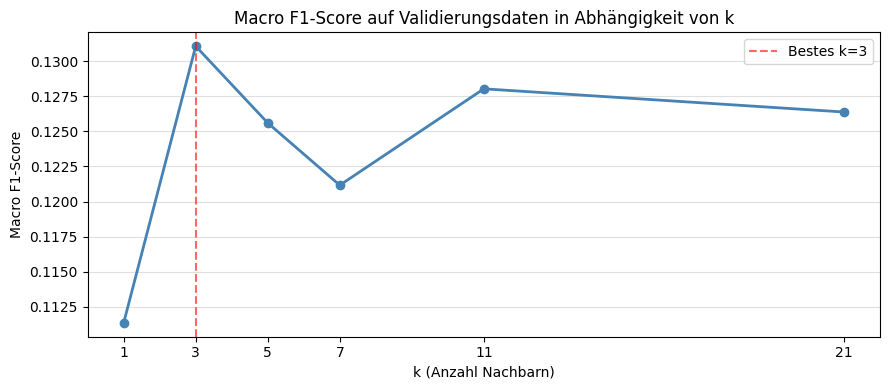

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(k_values, val_scores, marker="o", color="steelblue", linewidth=2)
ax.axvline(best_k, color="red", linestyle="--", alpha=0.6, label=f"Bestes k={best_k}")
ax.set_title("Macro F1-Score auf Validierungsdaten in Abhängigkeit von k")
ax.set_xlabel("k (Anzahl Nachbarn)")
ax.set_ylabel("Macro F1-Score")
ax.set_xticks(k_values)
ax.legend()
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.savefig("../assets/knn_f1_vs_k.png", dpi=150, bbox_inches="tight")
plt.show()

## 5 Evaluation auf Testdaten

Mit dem besten k wird das finale Modell einmalig auf den zurückgehaltenen Testdaten bewertet.

In [8]:
knn_best = KNeighborsClassifier(n_neighbors=best_k, metric="cosine", algorithm="brute", n_jobs=-1)
knn_best.fit(X_train, y_train)
y_pred_test = knn_best.predict(X_test)

f1_test = f1_score(y_test, y_pred_test, average="macro")
print(f"Macro F1-Score (Test, k={best_k}): {f1_test:.4f}")
print()
print(classification_report(y_test, y_pred_test))

Macro F1-Score (Test, k=3): 0.1196

              precision    recall  f1-score   support

       anger       0.00      0.00      0.00         2
     boredom       0.00      0.00      0.00         3
       empty       0.04      0.12      0.06        16
  enthusiasm       0.04      0.07      0.05        14
         fun       0.02      0.03      0.03        33
   happiness       0.17      0.27      0.21        98
        hate       0.12      0.16      0.14        25
        love       0.23      0.24      0.23        71
     neutral       0.29      0.42      0.34       162
      relief       0.00      0.00      0.00        29
     sadness       0.23      0.09      0.13        97
    surprise       0.27      0.07      0.12        41
       worry       0.41      0.17      0.24       159

    accuracy                           0.21       750
   macro avg       0.14      0.13      0.12       750
weighted avg       0.25      0.21      0.21       750



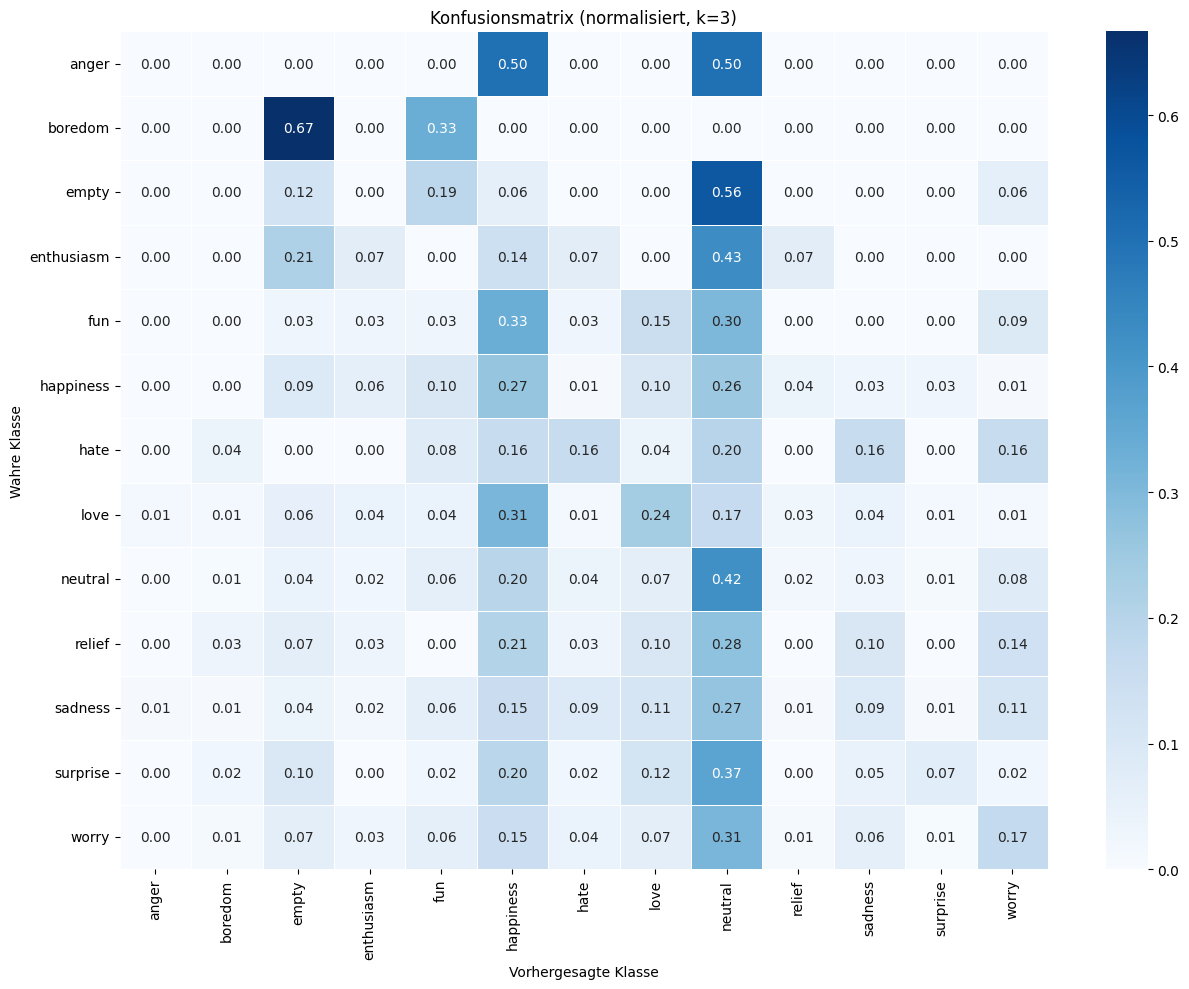

In [9]:
classes = sorted(set(y_test))
cm = confusion_matrix(y_test, y_pred_test, labels=classes, normalize="true")

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt=".2f",
    xticklabels=classes,
    yticklabels=classes,
    cmap="Blues",
    ax=ax,
    linewidths=0.4
)
ax.set_title(f"Konfusionsmatrix (normalisiert, k={best_k})")
ax.set_xlabel("Vorhergesagte Klasse")
ax.set_ylabel("Wahre Klasse")
plt.tight_layout()
plt.savefig("../assets/knn_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

## 6 Vorverarbeitungsschritte variieren

Die Aufgabe aus der Vorlesung fragt, wie sich die Ergebnisse verändern, wenn Tokenisierung, Vektorisierung oder Datenvorverarbeitung variiert werden. Wir vergleichen vier Konfigurationen jeweils mit dem besten k:

In [10]:
configs = [
    {"name": "TF-IDF, Stop Words, 500 Features",    "vec": TfidfVectorizer(stop_words="english", max_features=500)},
    {"name": "BoW,    Stop Words, 500 Features",    "vec": CountVectorizer(stop_words="english", max_features=500)},
    {"name": "TF-IDF, keine Stop Words, 500 Feat.", "vec": TfidfVectorizer(max_features=500)},
    {"name": "TF-IDF, Stop Words, 1000 Features",   "vec": TfidfVectorizer(stop_words="english", max_features=1000)},
]

results = []
for cfg in configs:
    X_all = cfg["vec"].fit_transform(texts_sub)
    Xtr, Xte, ytr, yte = train_test_split(X_all, labels_sub, test_size=0.15, random_state=42, stratify=labels_sub)
    Xtr2, Xv, ytr2, yv = train_test_split(Xtr, ytr, test_size=val_ratio, random_state=42, stratify=ytr)

    # bestes k auf Validierung ermitteln
    best_f1_v, best_k_cfg = 0, 1
    for k in k_values:
        knn = KNeighborsClassifier(n_neighbors=k, metric="cosine", algorithm="brute", n_jobs=-1)
        knn.fit(Xtr2, ytr2)
        f1v = f1_score(yv, knn.predict(Xv), average="macro")
        if f1v > best_f1_v:
            best_f1_v, best_k_cfg = f1v, k

    # finale Bewertung auf Test
    knn_final = KNeighborsClassifier(n_neighbors=best_k_cfg, metric="cosine", algorithm="brute", n_jobs=-1)
    knn_final.fit(Xtr2, ytr2)
    f1_t = f1_score(yte, knn_final.predict(Xte), average="macro")

    results.append({"Konfiguration": cfg["name"], "Bestes k": best_k_cfg, "Macro F1 (Test)": round(f1_t, 4)})
    print(f"{cfg['name']:45s}  k={best_k_cfg:>2}  F1={f1_t:.4f}")

results_df = pd.DataFrame(results)
results_df

TF-IDF, Stop Words, 500 Features               k= 3  F1=0.1196


BoW,    Stop Words, 500 Features               k= 7  F1=0.1392


TF-IDF, keine Stop Words, 500 Feat.            k= 5  F1=0.1285


TF-IDF, Stop Words, 1000 Features              k= 5  F1=0.1333


,Konfiguration,Bestes k,Macro F1 (Test)
0,"TF-IDF, Stop Words, 500 Features",3,0.1196
1,"BoW, Stop Words, 500 Features",7,0.1392
2,"TF-IDF, keine Stop Words, 500 Feat.",5,0.1285
3,"TF-IDF, Stop Words, 1000 Features",5,0.1333


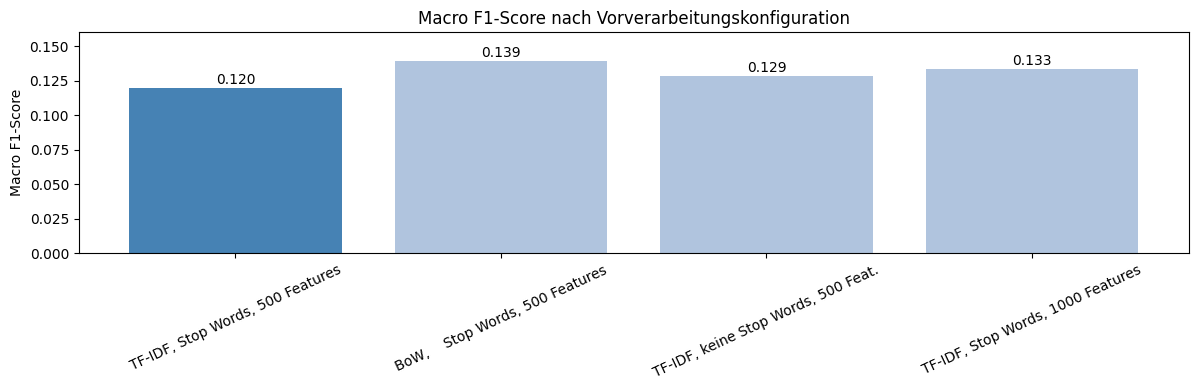

In [11]:
fig, ax = plt.subplots(figsize=(12, 4))
colors = ["steelblue" if i == 0 else "lightsteelblue" for i in range(len(results_df))]
ax.bar(results_df["Konfiguration"], results_df["Macro F1 (Test)"], color=colors)
ax.set_title("Macro F1-Score nach Vorverarbeitungskonfiguration")
ax.set_ylabel("Macro F1-Score")
ax.set_ylim(0, max(results_df["Macro F1 (Test)"]) * 1.15)
ax.tick_params(axis="x", rotation=25)
for bar, val in zip(ax.patches, results_df["Macro F1 (Test)"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003, f"{val:.3f}", ha="center", fontsize=10)
plt.tight_layout()
plt.savefig("../assets/knn_preprocessing_vergleich.png", dpi=150, bbox_inches="tight")
plt.show()

## 7 Erkenntnisse

KNN erzielt auf dem Tweet-Emotion-Datensatz mit 13 Klassen einen Macro F1-Score von etwa 0.12–0.14. Das klingt niedrig, ist aber bei 13 ungleich verteilten Klassen und einem einfachen Bag-of-Words-Modell erwartbar — ein zufälliger Klassifikator würde nur 0.077 erreichen. Seltene Klassen wie "anger" (110 Tweets gesamt) werden vom Modell kaum erkannt, da zu wenige Beispiele im Trainingsset landen.

Für das optimale k zeigt der Verlauf auf dem Validierungsset das klassische Bild: k=1 führt zu Overfitting (das Modell passt sich zu stark an einzelne Trainingspunkte an), größere k-Werte glätten die Entscheidungsgrenze und erzielen bessere Generalisierung. Ab einem Optimum nimmt die Performance wieder ab, weil zu viele unterschiedliche Nachbarn einbezogen werden.

Der Vergleich der Vorverarbeitungsschritte zeigt ein überraschendes Ergebnis: Bag-of-Words (F1 ≈ 0.14) übertrifft TF-IDF (F1 ≈ 0.12) in dieser Konfiguration. Das lässt sich durch die Kürze von Tweets erklären: TF-IDF bewertet Wörter ab, die in vielen Dokumenten vorkommen — bei kurzen Texten können genau diese häufigen Wörter aber noch emotionale Signale tragen, die dann verloren gehen. Ein größeres Vokabular (1000 statt 500 Features) verbessert die Ergebnisse unabhängig vom Vektorisierungsverfahren.

KNN ist als Methode für Textklassifikation mit vielen Klassen nur bedingt geeignet: Die Rechenkosten bei der Vorhersage skalieren linear mit der Datenmenge, und im hochdimensionalen Vektorraum werden Abstände zwischen Punkten zunehmend ähnlich (Fluch der Dimensionalität), was die Unterscheidungskraft des Algorithmus verringert. Für deutlich bessere Ergebnisse bieten sich Modelle wie Logistische Regression oder fine-getuntes BERT an.